# Sarcasm detector — evaluation analysis

This notebook loads job and verdict data from the SQLite database and plots descriptive charts.
Each section states what is plotted (variables, axes, filters). It does **not** interpret model performance or sarcasm-detection quality.

Prerequisite: run `python -m sarcasm_detector parse` so `job_verdicts` is populated.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DB_PATH = Path(os.environ.get("SQLITE_DB", "../sarcasm.db"))
if not DB_PATH.is_file():
    raise FileNotFoundError(f"Database not found: {DB_PATH.resolve()}")

## Load data

One row per job, joined with model, clip, series, latest job output, and parsed verdict (if any).
This section describes the dataset only; it does not interpret model performance.

In [2]:
QUERY = """
SELECT
    j.id AS job_id,
    j.status AS job_status,
    j.modality,
    j.language,
    j.attempt_count,
    j.last_error,
    j.created_at,
    j.finished_at,
    m.name AS model,
    m.supports_audio,
    s.name AS series,
    c.id AS clip_id,
    c.episode,
    c.ground_truth_sarcasm,
    v.verdict,
    v.sarcastic,
    v.confidence,
    v.parse_error,
    v.parsed_at,
    jo.duration_ms,
    jo.http_status
FROM jobs j
JOIN models m ON m.id = j.model_id
JOIN clips c ON c.id = j.clip_id
JOIN series s ON s.id = c.series_id
LEFT JOIN job_verdicts v ON v.job_id = j.id
LEFT JOIN job_outputs jo ON jo.id = (
    SELECT id FROM job_outputs
    WHERE job_id = j.id
    ORDER BY id DESC
    LIMIT 1
)
ORDER BY j.id
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(QUERY, conn)

df["ground_truth_label"] = df["ground_truth_sarcasm"].map(
    {1: True, 0: False}
)
parsed_mask = df["verdict"].isin(["SARCASTIC", "NOT_SARCASTIC"])
non_exec_err_mask = df["verdict"].ne("EXEC_ERR")
df["prediction_label"] = pd.Series([None] * len(df), dtype=object)
df.loc[parsed_mask, "prediction_label"] = df.loc[parsed_mask, "sarcastic"].astype(bool)
has_prediction = df["prediction_label"].notna()
df["matches_ground_truth"] = np.nan
df.loc[has_prediction, "matches_ground_truth"] = (
    df.loc[has_prediction, "ground_truth_label"]
    == df.loc[has_prediction, "prediction_label"]
)

verdict_count = df["verdict"].notna().sum()
unparsed = len(df) - verdict_count

print(f"Database: {DB_PATH.resolve()}")
print(f"Rows (jobs): {len(df)}")
print(f"Clips: {df['clip_id'].nunique()}")
print(f"Models: {df['model'].nunique()}")
print(f"Series: {df['series'].nunique()}")
print(f"Parsed verdicts: {verdict_count}")
print(f"Jobs without verdict row: {unparsed}")
if unparsed > 0:
    print("Note: run `python -m sarcasm_detector parse` to populate job_verdicts.")
if verdict_count == 0:
    print("Warning: job_verdicts is empty — verdict and confidence charts will be skipped.")

display(df.head())

Database: /home/alessioc42/Documents/GitHub/gh-sarcasm-detector/sarcasm.db
Rows (jobs): 4752
Clips: 83
Models: 18
Series: 7
Parsed verdicts: 4488
Jobs without verdict row: 264
Note: run `python -m sarcasm_detector parse` to populate job_verdicts.


/tmp/ipykernel_20706/2571526099.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False  True  True ...  True  True  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[has_prediction, "matches_ground_truth"] = (


,job_id,job_status,modality,language,attempt_count,last_error,created_at,finished_at,model,supports_audio,...,verdict,sarcastic,confidence,parse_error,parsed_at,duration_ms,http_status,ground_truth_label,prediction_label,matches_ground_truth
0,1,pending,audio,en,0,None,2026-06-14 08:31:11,None,llama3.2,NaN,...,None,NaN,NaN,None,None,NaN,NaN,True,None,NaN
1,2,pending,text,en,0,None,2026-06-14 08:31:11,None,llama3.2,NaN,...,None,NaN,NaN,None,None,NaN,NaN,True,None,NaN
2,3,pending,audio,en,0,None,2026-06-14 08:31:11,None,llama3.2,NaN,...,None,NaN,NaN,None,None,NaN,NaN,True,None,NaN
3,4,pending,text,en,0,None,2026-06-14 08:31:11,None,llama3.2,NaN,...,None,NaN,NaN,None,None,NaN,NaN,True,None,NaN
4,5,pending,audio,en,0,None,2026-06-14 08:31:11,None,llama3.2,NaN,...,None,NaN,NaN,None,None,NaN,NaN,True,None,NaN


In [3]:
# Summary counts
summary = pd.DataFrame(
    {
        "metric": [
            "jobs",
            "models",
            "series",
            "parsed_verdicts",
            "jobs_without_verdict",
        ],
        "count": [
            len(df),
            df["model"].nunique(),
            df["series"].nunique(),
            df["verdict"].notna().sum(),
            df["verdict"].isna().sum(),
        ],
    }
)
display(summary)
display(df["job_status"].value_counts().rename_axis("job_status").reset_index(name="count"))

,metric,count
0,jobs,4752
1,models,18
2,series,7
3,parsed_verdicts,4488
4,jobs_without_verdict,264


,job_status,count
0,completed,2592
1,skipped,1845
2,pending,264
3,failed,51


## Execution status

**Figure:** Bar chart of job counts by `jobs.status`.

- **X-axis:** job status (`pending`, `running`, `completed`, `failed`, `skipped`)
- **Y-axis:** number of jobs
- **Filter:** none (all jobs)

This section describes the chart only; it does not interpret model performance.

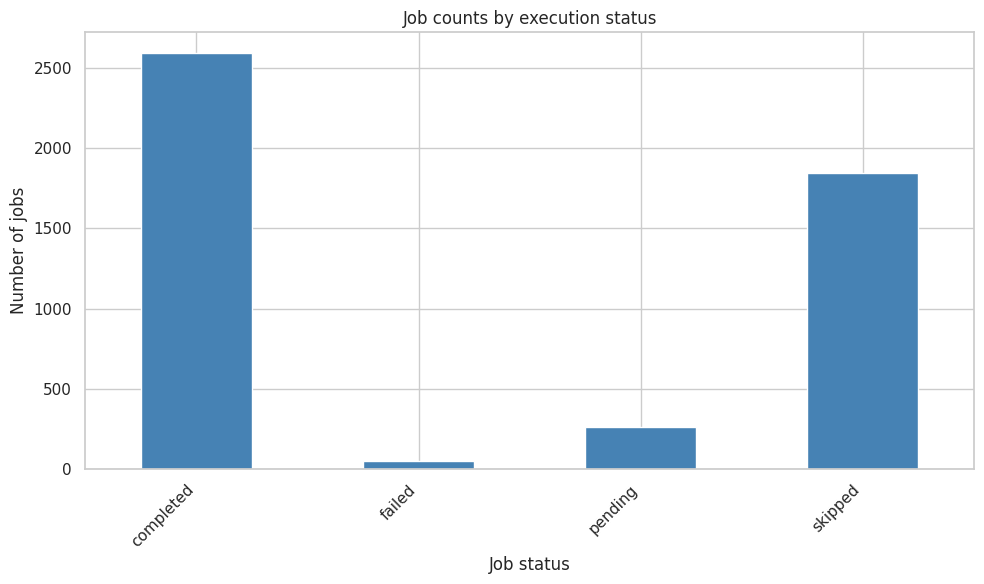

In [4]:
status_counts = df["job_status"].value_counts().sort_index()
fig, ax = plt.subplots()
status_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Job status")
ax.set_ylabel("Number of jobs")
ax.set_title("Job counts by execution status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Verdict overview

**Figure:** Bar chart of job counts by `job_verdicts.verdict`.

- **X-axis:** verdict (`SARCASTIC`, `NOT_SARCASTIC`, `LLM_ERR`, `EXEC_ERR`)
- **Y-axis:** number of jobs with a verdict row
- **Filter:** rows where `verdict` is not null

This section describes the chart only; it does not interpret model performance.

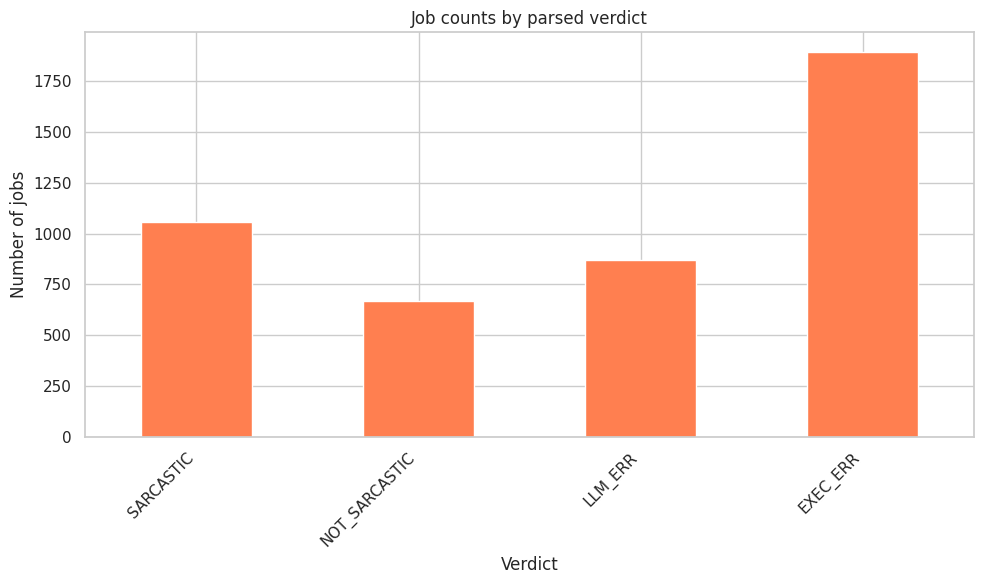

In [5]:
parsed = df.dropna(subset=["verdict"])
if parsed.empty:
    print("No parsed verdicts — skip chart.")
else:
    verdict_order = ["SARCASTIC", "NOT_SARCASTIC", "LLM_ERR", "EXEC_ERR"]
    vc = parsed["verdict"].value_counts().reindex(
        [v for v in verdict_order if v in parsed["verdict"].values]
    )
    fig, ax = plt.subplots()
    vc.plot(kind="bar", ax=ax, color="coral")
    ax.set_xlabel("Verdict")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Job counts by parsed verdict")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Figure:** Pie chart of verdict proportions among parsed jobs.

- **Slices:** share of each verdict among rows with non-null `verdict`
- **Filter:** parsed jobs only

This section describes the chart only; it does not interpret model performance.

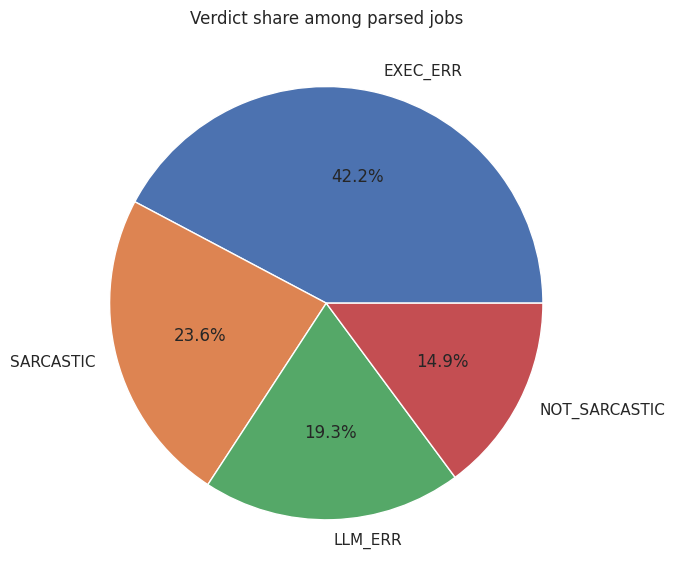

In [6]:
if parsed.empty:
    print("No parsed verdicts — skip chart.")
else:
    fig, ax = plt.subplots()
    parsed["verdict"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%")
    ax.set_ylabel("")
    ax.set_title("Verdict share among parsed jobs")
    plt.tight_layout()
    plt.show()

**Figure:** Grouped bar chart — verdict counts by model (`models.name`).

- **X-axis:** model name
- **Y-axis:** number of jobs
- **Color/group:** verdict
- **Filter:** parsed jobs only

This section describes the chart only; it does not interpret model performance.

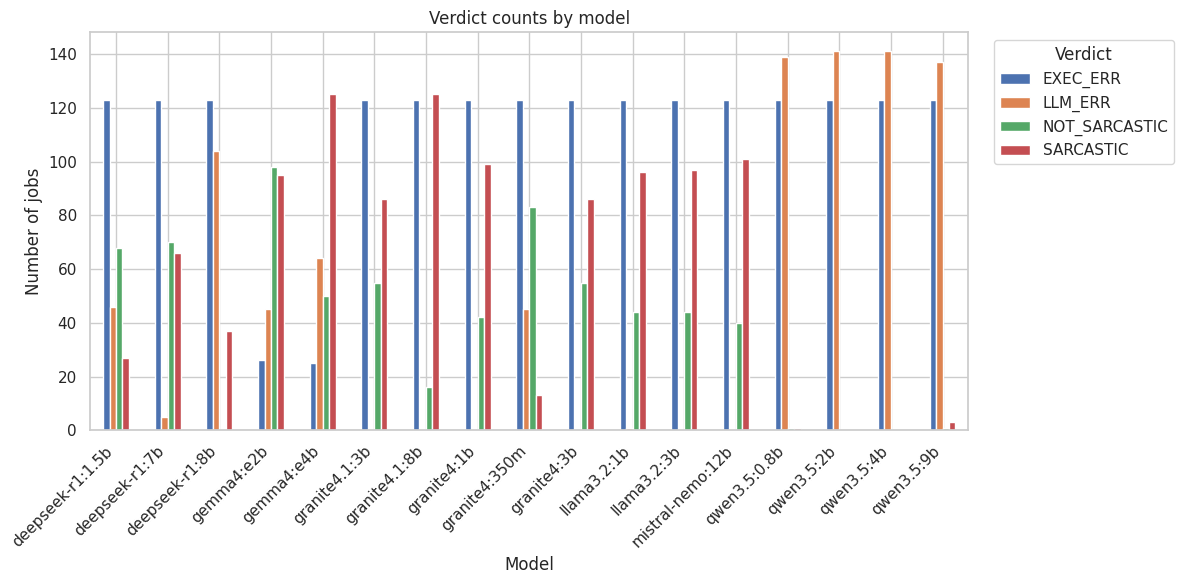

In [7]:
if parsed.empty:
    print("No parsed verdicts — skip chart.")
else:
    cross = pd.crosstab(parsed["model"], parsed["verdict"])
    fig, ax = plt.subplots(figsize=(12, 6))
    cross.plot(kind="bar", ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Verdict counts by model")
    ax.legend(title="Verdict", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Figure:** Grouped bar chart — verdict counts by modality (`text` vs `audio`).

- **X-axis:** modality
- **Y-axis:** number of jobs
- **Color/group:** verdict
- **Filter:** parsed jobs only

This section describes the chart only; it does not interpret model performance.

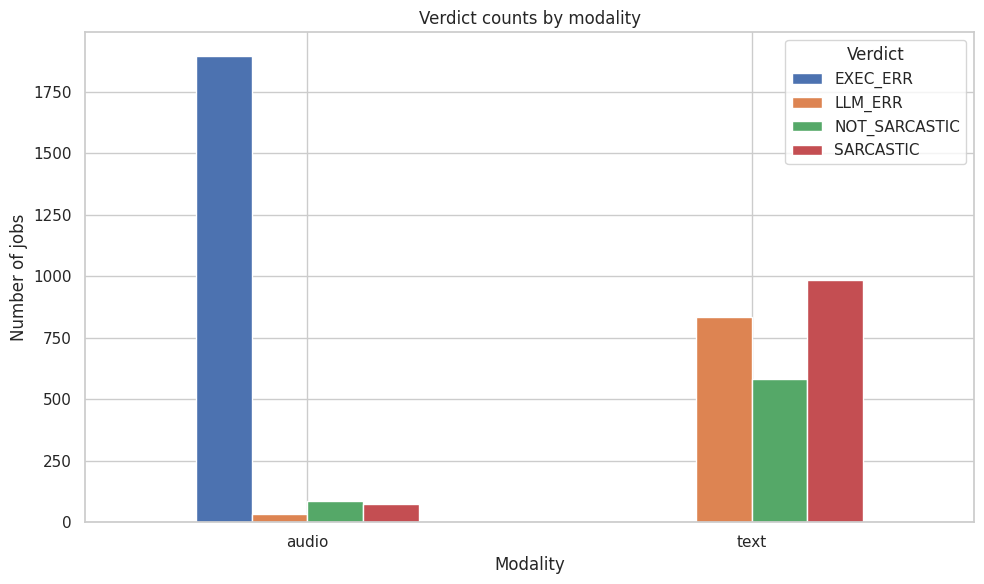

In [8]:
if parsed.empty:
    print("No parsed verdicts — skip chart.")
else:
    cross = pd.crosstab(parsed["modality"], parsed["verdict"])
    fig, ax = plt.subplots()
    cross.plot(kind="bar", ax=ax)
    ax.set_xlabel("Modality")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Verdict counts by modality")
    ax.legend(title="Verdict")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Figure:** Grouped bar chart — verdict counts by language (`en` vs `de`).

- **X-axis:** language
- **Y-axis:** number of jobs
- **Color/group:** verdict
- **Filter:** parsed jobs only

This section describes the chart only; it does not interpret model performance.

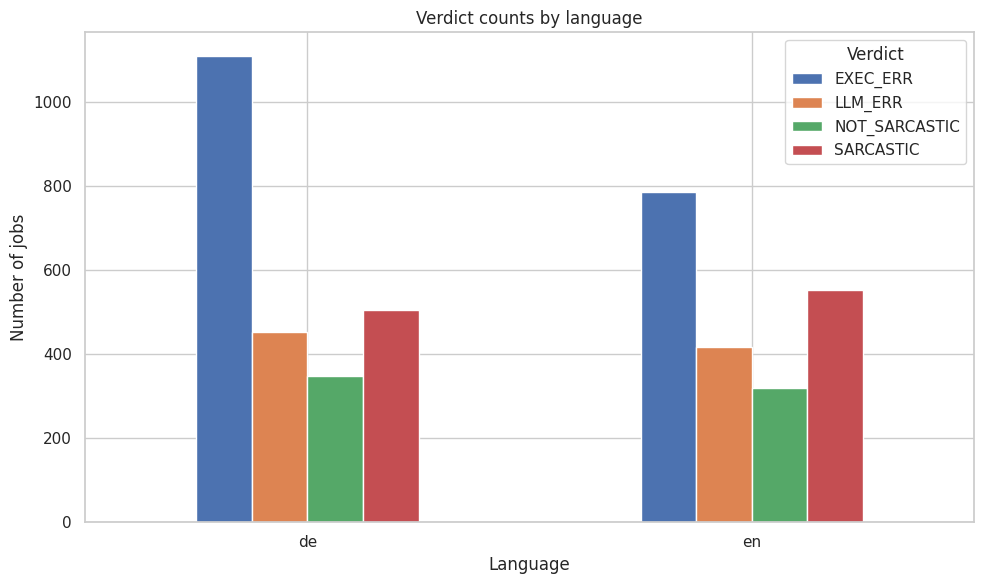

In [9]:
if parsed.empty:
    print("No parsed verdicts — skip chart.")
else:
    cross = pd.crosstab(parsed["language"], parsed["verdict"])
    fig, ax = plt.subplots()
    cross.plot(kind="bar", ax=ax)
    ax.set_xlabel("Language")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Verdict counts by language")
    ax.legend(title="Verdict")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Dataset breakdown

**Figure:** Bar chart of job counts per series (`series.name`).

- **X-axis:** series name
- **Y-axis:** number of jobs
- **Filter:** all jobs

This section describes the chart only; it does not interpret model performance.

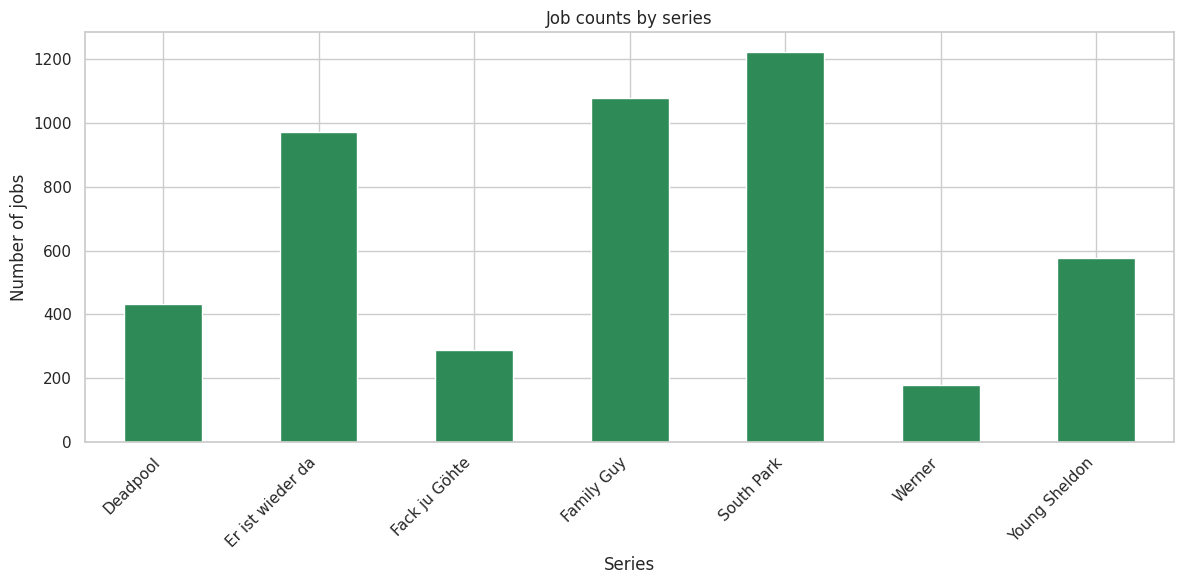

In [10]:
series_counts = df["series"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
series_counts.plot(kind="bar", ax=ax, color="seagreen")
ax.set_xlabel("Series")
ax.set_ylabel("Number of jobs")
ax.set_title("Job counts by series")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Figure:** Grouped bar chart — verdict counts per series.

- **X-axis:** series name
- **Y-axis:** number of jobs
- **Color/group:** verdict
- **Filter:** parsed jobs only

This section describes the chart only; it does not interpret model performance.

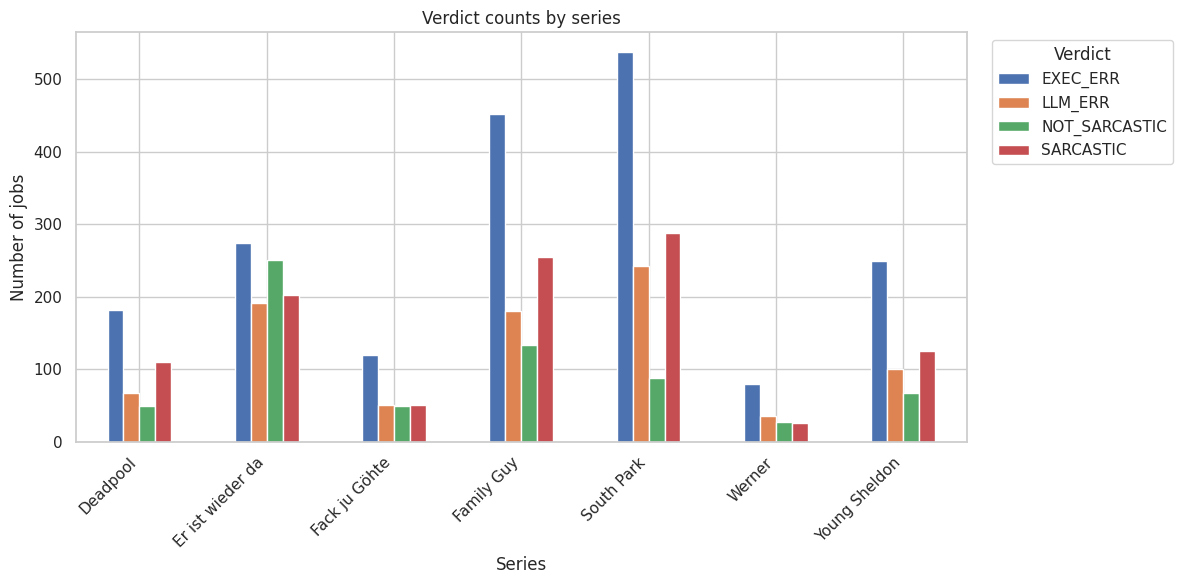

In [11]:
if parsed.empty:
    print("No parsed verdicts — skip chart.")
else:
    cross = pd.crosstab(parsed["series"], parsed["verdict"])
    fig, ax = plt.subplots(figsize=(12, 6))
    cross.plot(kind="bar", ax=ax)
    ax.set_xlabel("Series")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Verdict counts by series")
    ax.legend(title="Verdict", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Figure:** Heatmap of job counts — model (rows) × modality (columns).

- **Cell value:** number of jobs for that model and modality
- **Filter:** all jobs

This section describes the chart only; it does not interpret model performance.

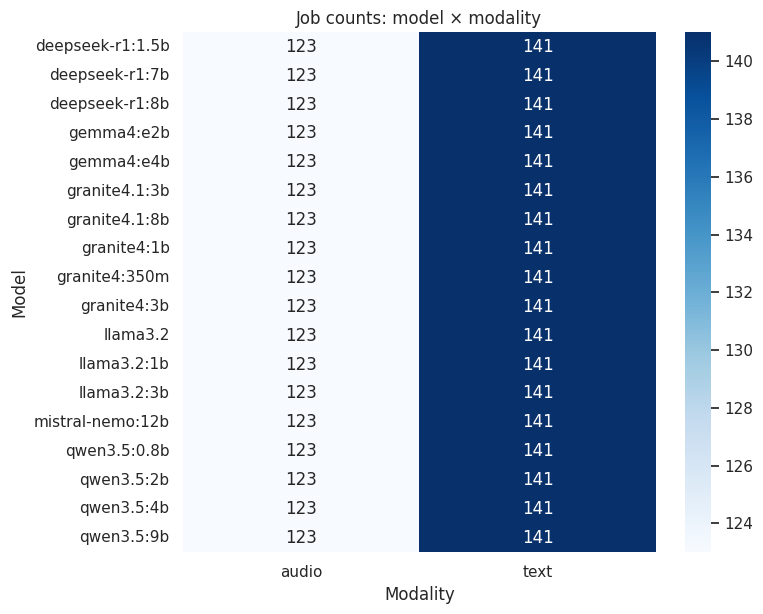

In [12]:
pivot_mm = df.pivot_table(
    index="model", columns="modality", values="job_id", aggfunc="count", fill_value=0
)
fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_mm) * 0.35)))
sns.heatmap(pivot_mm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Job counts: model × modality")
ax.set_xlabel("Modality")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

**Figure:** Heatmap of job counts — modality (rows) × language (columns).

- **Cell value:** number of jobs for that modality and language pair
- **Filter:** all jobs

This section describes the chart only; it does not interpret model performance.

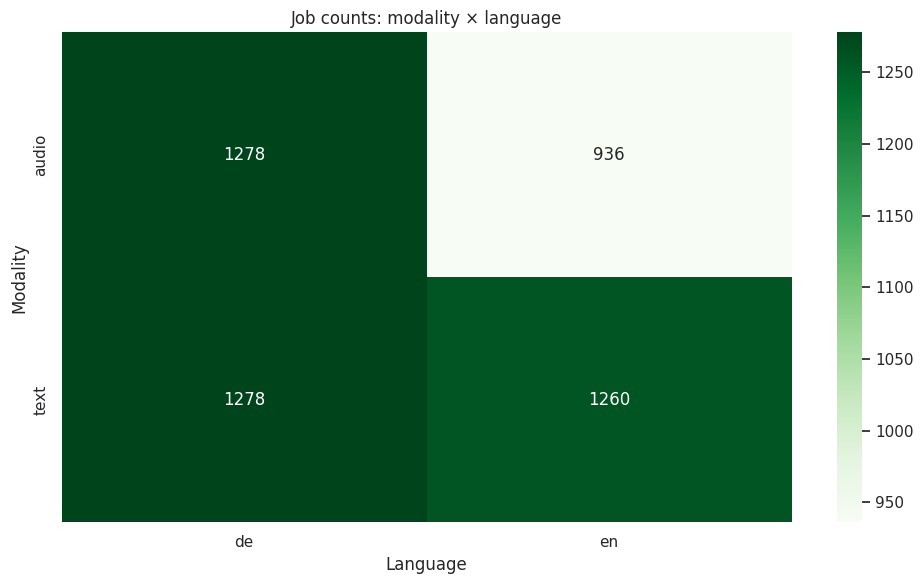

In [13]:
pivot_ml = df.pivot_table(
    index="modality", columns="language", values="job_id", aggfunc="count", fill_value=0
)
fig, ax = plt.subplots()
sns.heatmap(pivot_ml, annot=True, fmt="d", cmap="Greens", ax=ax)
ax.set_title("Job counts: modality × language")
ax.set_xlabel("Language")
ax.set_ylabel("Modality")
plt.tight_layout()
plt.show()

## Confidence scores

**Figure:** Histogram of LLM-reported confidence (integer 0–10).

- **X-axis:** confidence score
- **Y-axis:** frequency (number of jobs)
- **Filter:** rows where `confidence` is not null

This section describes the chart only; it does not interpret model performance.

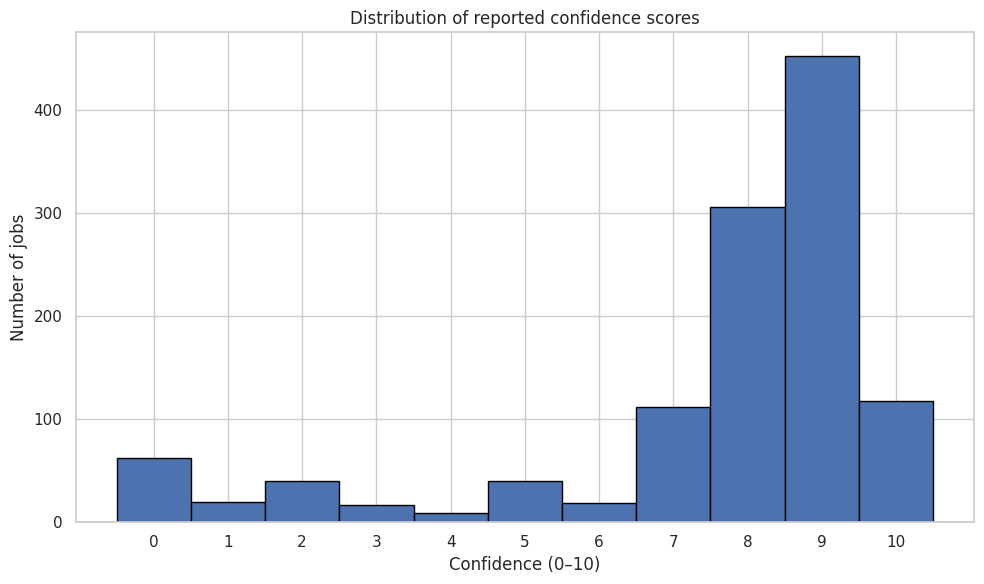

In [14]:
conf = df.dropna(subset=["confidence"])
if conf.empty:
    print("No confidence values — skip chart.")
else:
    fig, ax = plt.subplots()
    ax.hist(conf["confidence"], bins=range(0, 12), edgecolor="black", align="left")
    ax.set_xlabel("Confidence (0–10)")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Distribution of reported confidence scores")
    ax.set_xticks(range(0, 11))
    plt.tight_layout()
    plt.show()

**Figure:** Overlaid histograms of confidence by verdict (`SARCASTIC` vs `NOT_SARCASTIC`).

- **X-axis:** confidence score
- **Y-axis:** frequency
- **Filter:** non-null confidence and verdict in `{SARCASTIC, NOT_SARCASTIC}`

This section describes the chart only; it does not interpret model performance.

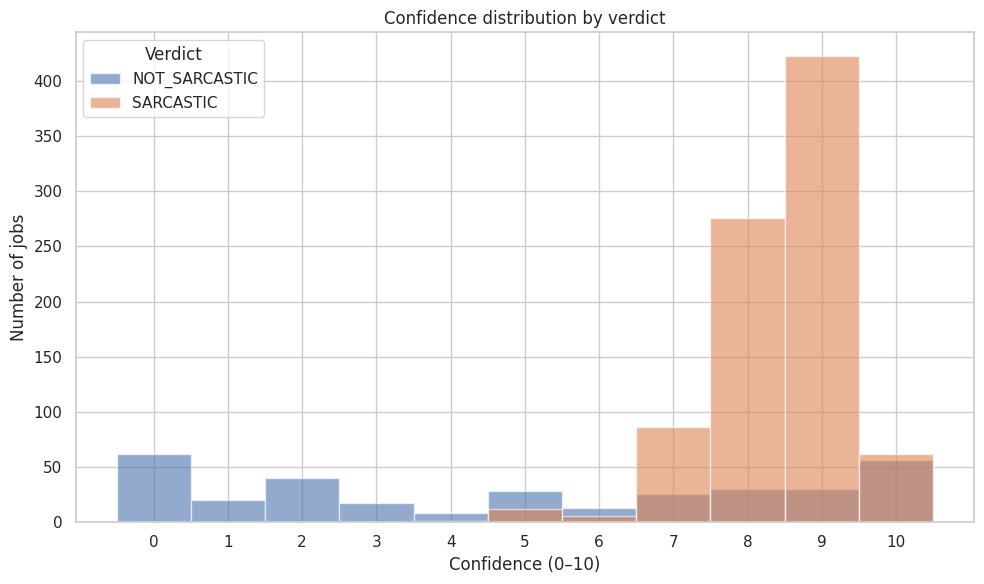

In [15]:
conf_v = conf[conf["verdict"].isin(["SARCASTIC", "NOT_SARCASTIC"])]
if conf_v.empty:
    print("No confidence with SARCASTIC/NOT_SARCASTIC verdict — skip chart.")
else:
    fig, ax = plt.subplots()
    for verdict, group in conf_v.groupby("verdict"):
        ax.hist(
            group["confidence"],
            bins=range(0, 12),
            alpha=0.6,
            label=verdict,
            align="left",
        )
    ax.set_xlabel("Confidence (0–10)")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Confidence distribution by verdict")
    ax.set_xticks(range(0, 11))
    ax.legend(title="Verdict")
    plt.tight_layout()
    plt.show()

**Figure:** Boxplot of confidence by model.

- **X-axis:** model name
- **Y-axis:** confidence (0–10)
- **Filter:** non-null confidence

This section describes the chart only; it does not interpret model performance.

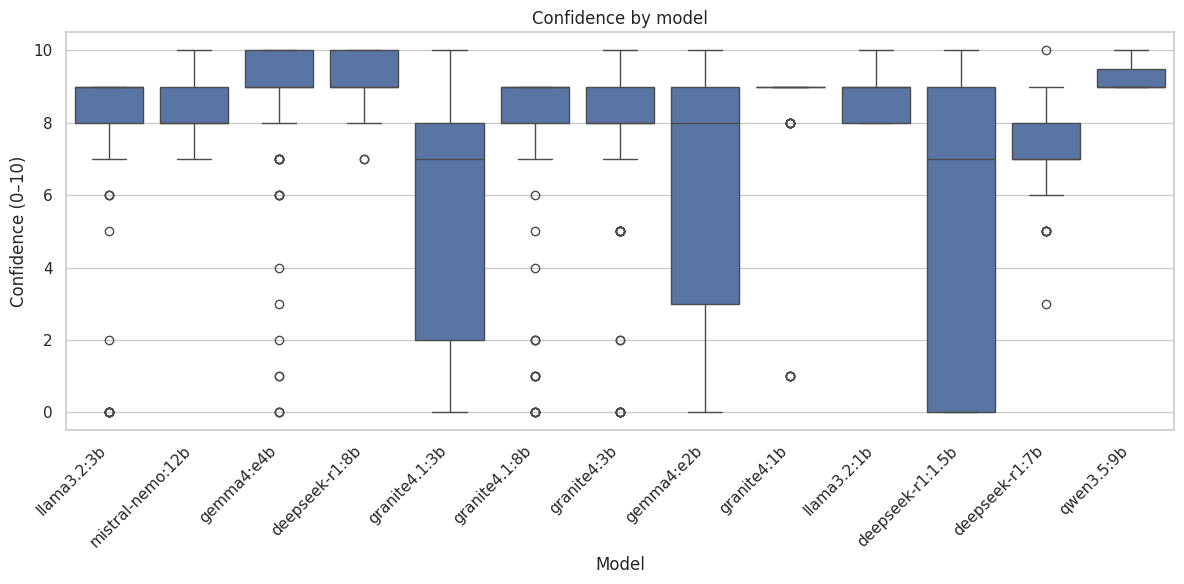

In [16]:
if conf.empty:
    print("No confidence values — skip chart.")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=conf, x="model", y="confidence", ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Confidence (0–10)")
    ax.set_title("Confidence by model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Figure:** Boxplot of confidence by modality.

- **X-axis:** modality
- **Y-axis:** confidence (0–10)
- **Filter:** non-null confidence

This section describes the chart only; it does not interpret model performance.

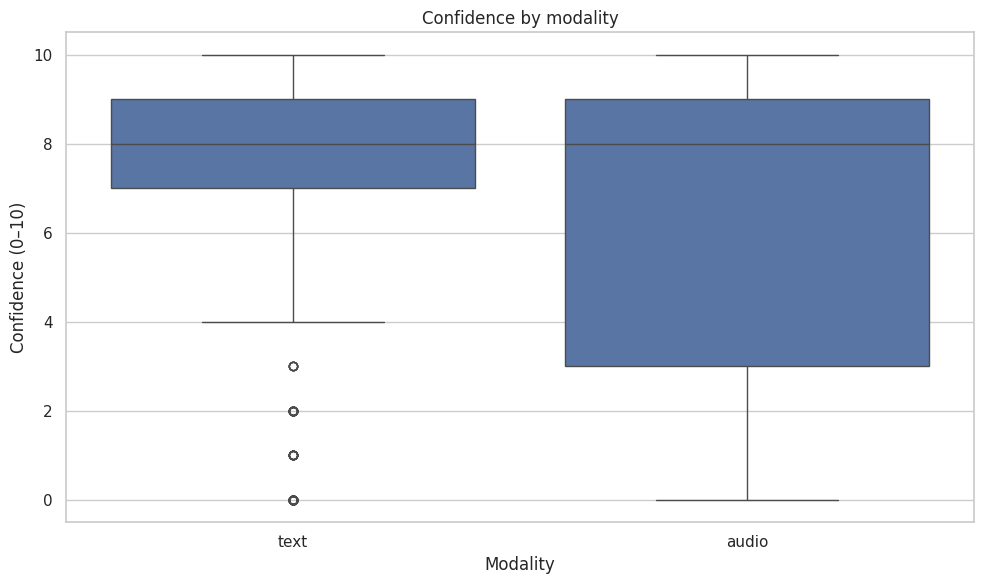

In [17]:
if conf.empty:
    print("No confidence values — skip chart.")
else:
    fig, ax = plt.subplots()
    sns.boxplot(data=conf, x="modality", y="confidence", ax=ax)
    ax.set_xlabel("Modality")
    ax.set_ylabel("Confidence (0–10)")
    ax.set_title("Confidence by modality")
    plt.tight_layout()
    plt.show()

**Figure:** Boxplot of confidence by language.

- **X-axis:** language
- **Y-axis:** confidence (0–10)
- **Filter:** non-null confidence

This section describes the chart only; it does not interpret model performance.

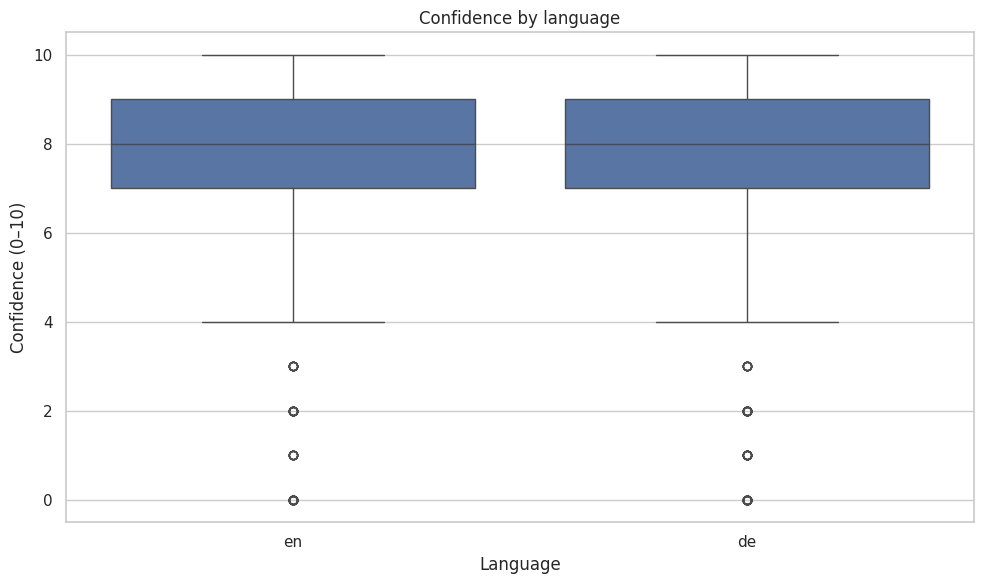

In [18]:
if conf.empty:
    print("No confidence values — skip chart.")
else:
    fig, ax = plt.subplots()
    sns.boxplot(data=conf, x="language", y="confidence", ax=ax)
    ax.set_xlabel("Language")
    ax.set_ylabel("Confidence (0–10)")
    ax.set_title("Confidence by language")
    plt.tight_layout()
    plt.show()

## Ground truth alignment

All charts in this section exclude jobs with verdict `EXEC_ERR`.

**Figure:** Heatmap (confusion-style matrix, row percentages).

- **Rows:** ground truth sarcasm label (`True` / `False` from `clips.ground_truth_sarcasm`)
- **Columns:** parsed sarcastic label (`True` / `False` from `job_verdicts.sarcastic`)
- **Cell value:** percentage of jobs within that ground-truth row (each row sums to 100%)
- **Filter:** non-null ground truth, verdict not `EXEC_ERR`, verdict in `{SARCASTIC, NOT_SARCASTIC}`

This section describes the chart only; it does not interpret model performance.

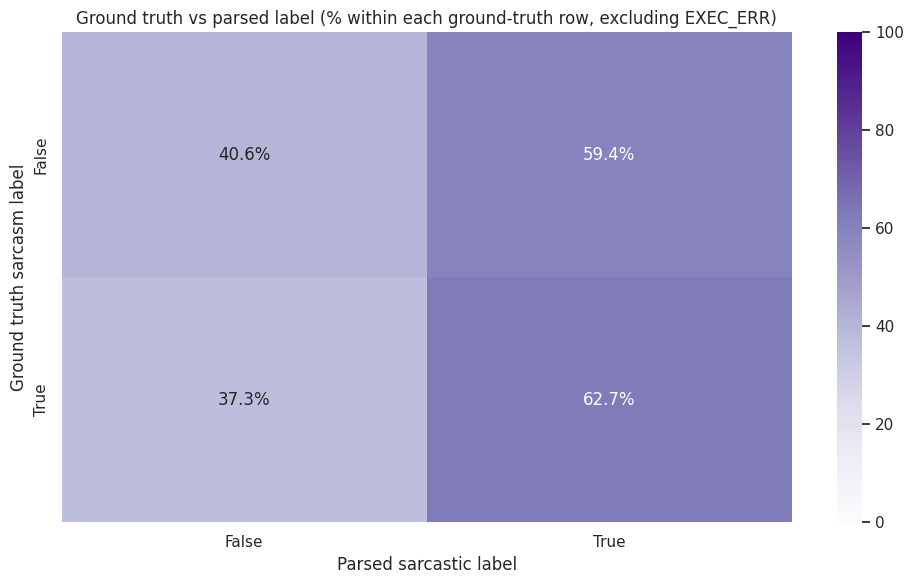

In [19]:
gt_all = df[df["ground_truth_label"].notna() & non_exec_err_mask].copy()
gt_all["matched"] = False
has_prediction = gt_all["prediction_label"].notna()
gt_all.loc[has_prediction, "matched"] = (
    gt_all.loc[has_prediction, "ground_truth_label"]
    == gt_all.loc[has_prediction, "prediction_label"]
)

gt = gt_all[gt_all["verdict"].isin(["SARCASTIC", "NOT_SARCASTIC"])].copy()
if gt.empty:
    print("No rows with ground truth and parsed label (excluding EXEC_ERR) — skip chart.")
else:
    gt["ground_truth_str"] = gt["ground_truth_label"].map({True: "True", False: "False"})
    gt["prediction_str"] = gt["prediction_label"].map({True: "True", False: "False"})
    cm = pd.crosstab(gt["ground_truth_str"], gt["prediction_str"])
    cm_pct = cm.div(cm.sum(axis=1), axis=0) * 100
    annot = cm_pct.map(lambda x: f"{x:.1f}%")
    fig, ax = plt.subplots()
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Purples", ax=ax, vmin=0, vmax=100)
    ax.set_xlabel("Parsed sarcastic label")
    ax.set_ylabel("Ground truth sarcasm label")
    ax.set_title("Ground truth vs parsed label (% within each ground-truth row, excluding EXEC_ERR)")
    plt.tight_layout()
    plt.show()

**Figure:** Bar chart — ground-truth match rate (%) per model.

- **X-axis:** model name
- **Y-axis:** percentage of jobs where parsed label matches ground truth (0–100%)
- **Filter:** non-null ground truth and verdict not `EXEC_ERR` (includes `LLM_ERR` as non-match)
- **Formula:** `matched jobs / eligible jobs × 100` per model

This section describes the chart only; it does not interpret model performance.

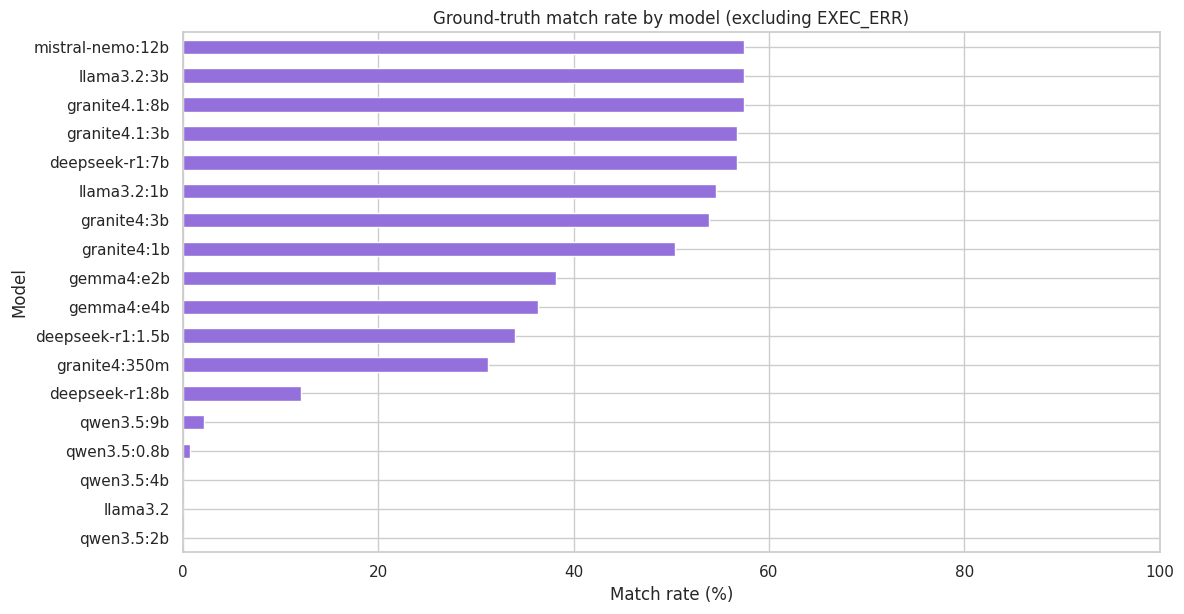

In [20]:
if gt_all.empty:
    print("No rows with ground truth (excluding EXEC_ERR) — skip chart.")
else:
    match_pct = gt_all.groupby("model")["matched"].mean() * 100
    match_pct = match_pct.sort_values()
    fig, ax = plt.subplots(figsize=(12, max(4, len(match_pct) * 0.35)))
    match_pct.plot(kind="barh", ax=ax, color="mediumpurple")
    ax.set_xlabel("Match rate (%)")
    ax.set_ylabel("Model")
    ax.set_title("Ground-truth match rate by model (excluding EXEC_ERR)")
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()

**Figure:** Bar chart — ground-truth match rate (%) per series.

- **X-axis:** series name
- **Y-axis:** percentage of jobs where parsed label matches ground truth (0–100%)
- **Filter:** non-null ground truth and verdict not `EXEC_ERR` (includes `LLM_ERR` as non-match)
- **Formula:** `matched jobs / eligible jobs × 100` per series

This section describes the chart only; it does not interpret model performance.

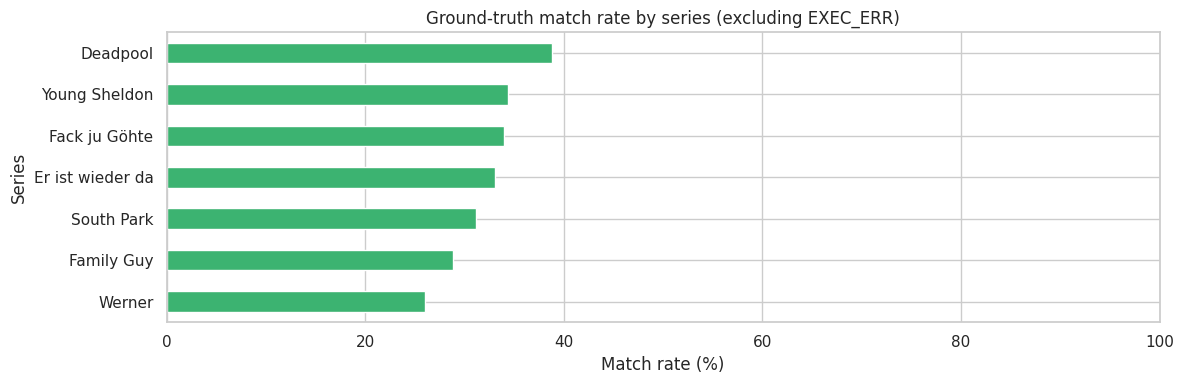

In [21]:
if gt_all.empty:
    print("No rows with ground truth (excluding EXEC_ERR) — skip chart.")
else:
    match_pct = gt_all.groupby("series")["matched"].mean() * 100
    match_pct = match_pct.sort_values()
    fig, ax = plt.subplots(figsize=(12, max(4, len(match_pct) * 0.35)))
    match_pct.plot(kind="barh", ax=ax, color="mediumseagreen")
    ax.set_xlabel("Match rate (%)")
    ax.set_ylabel("Series")
    ax.set_title("Ground-truth match rate by series (excluding EXEC_ERR)")
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()

## Runtime and errors

**Figure:** Histogram of inference duration (`job_outputs.duration_ms`) for completed jobs.

- **X-axis:** duration in milliseconds
- **Y-axis:** frequency
- **Filter:** `job_status == completed` and non-null `duration_ms`

This section describes the chart only; it does not interpret model performance.

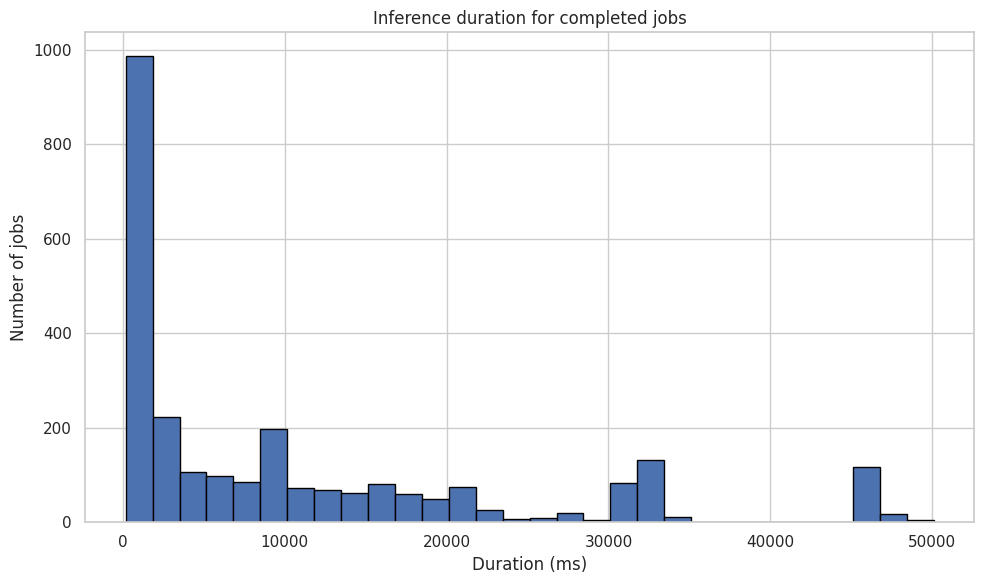

In [22]:
dur = df[(df["job_status"] == "completed") & df["duration_ms"].notna()]
if dur.empty:
    print("No completed jobs with duration — skip chart.")
else:
    fig, ax = plt.subplots()
    ax.hist(dur["duration_ms"], bins=30, edgecolor="black")
    ax.set_xlabel("Duration (ms)")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Inference duration for completed jobs")
    plt.tight_layout()
    plt.show()

**Figure:** Boxplot of inference duration by model.

- **X-axis:** model name
- **Y-axis:** duration (ms)
- **Filter:** completed jobs with non-null `duration_ms`

This section describes the chart only; it does not interpret model performance.

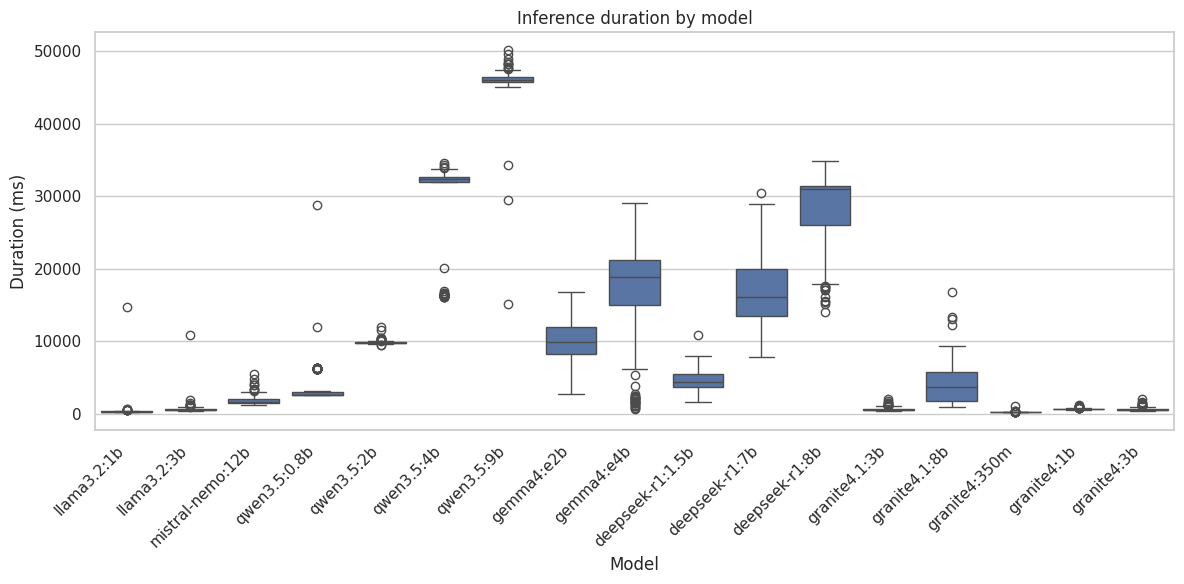

In [23]:
if dur.empty:
    print("No completed jobs with duration — skip chart.")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=dur, x="model", y="duration_ms", ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Duration (ms)")
    ax.set_title("Inference duration by model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Figure:** Boxplot of inference duration by modality.

- **X-axis:** modality
- **Y-axis:** duration (ms)
- **Filter:** completed jobs with non-null `duration_ms`

This section describes the chart only; it does not interpret model performance.

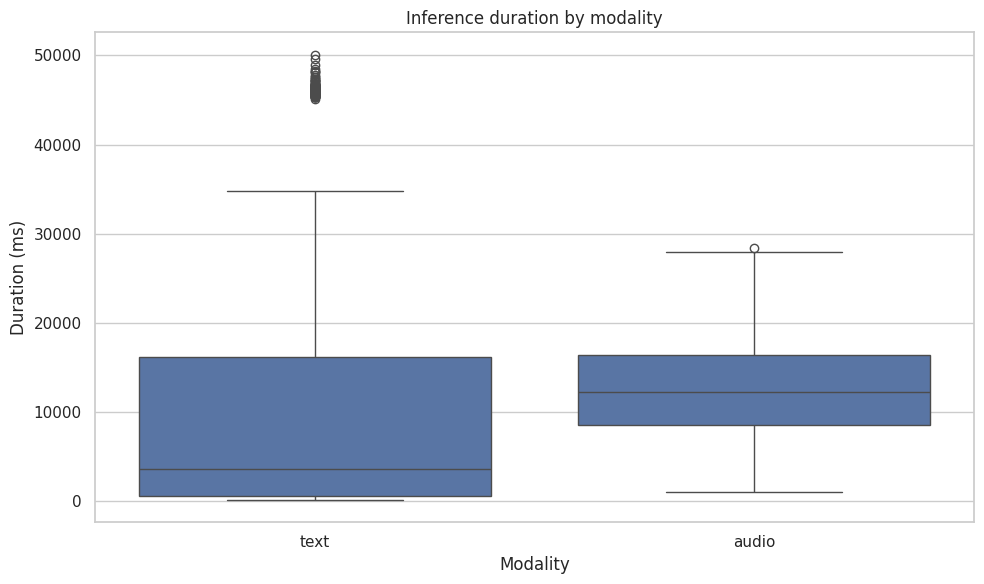

In [24]:
if dur.empty:
    print("No completed jobs with duration — skip chart.")
else:
    fig, ax = plt.subplots()
    sns.boxplot(data=dur, x="modality", y="duration_ms", ax=ax)
    ax.set_xlabel("Modality")
    ax.set_ylabel("Duration (ms)")
    ax.set_title("Inference duration by modality")
    plt.tight_layout()
    plt.show()

**Figure:** Bar chart of error verdict counts (`LLM_ERR` vs `EXEC_ERR`).

- **X-axis:** error verdict type
- **Y-axis:** number of jobs
- **Filter:** verdict in `{LLM_ERR, EXEC_ERR}`

This section describes the chart only; it does not interpret model performance.

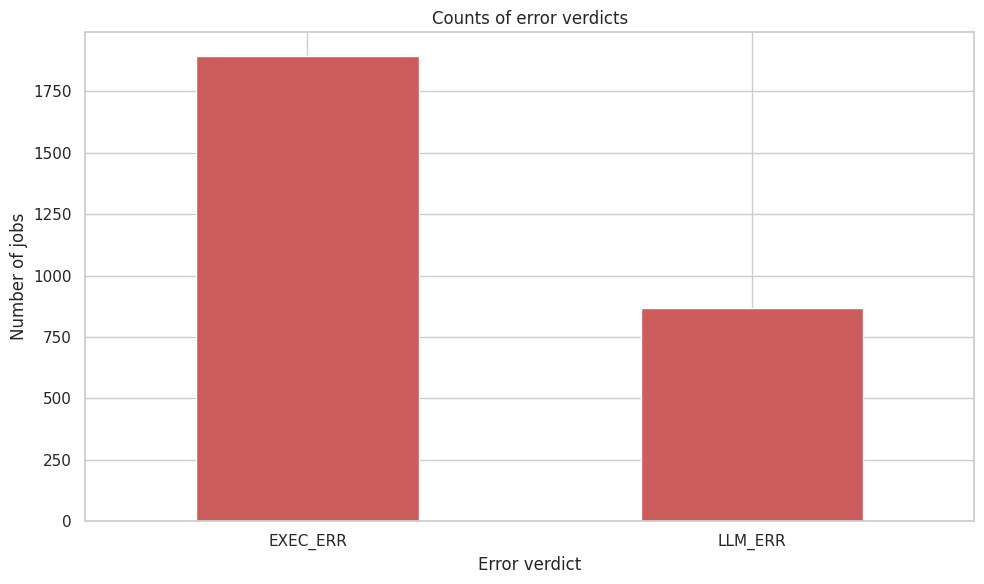

In [25]:
errors = df[df["verdict"].isin(["LLM_ERR", "EXEC_ERR"])]
if errors.empty:
    print("No LLM_ERR or EXEC_ERR verdicts — skip chart.")
else:
    fig, ax = plt.subplots()
    errors["verdict"].value_counts().plot(kind="bar", ax=ax, color="indianred")
    ax.set_xlabel("Error verdict")
    ax.set_ylabel("Number of jobs")
    ax.set_title("Counts of error verdicts")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()